## **DATA ANALYSIS WORKFLOW:**
 
1. Importing Libraries
 
2. Importing dataset
 
3. Understand the data (EDA- Exploratory Data Analysis)
 
4. Data Preprocessing:
 
Missing Values
 
Null Values
 
Invalid values
 
Encoding(If needed)
 
5. Scaling
 
6. Visualization/analysis
 
 - Univariate
 
 - Bi-Variate
 
 - Multi-variate
 
7. Insights/Conclusion from visualizations

# importing libraries

In [59]:
pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

 # importing dataset

In [61]:
df = pd.read_csv(r"D:\AICTW\EDA\bank_customer data.csv", skiprows=2)
df.head

<bound method NDFrame.head of        customerid   age  salary  balance   marital                  jobedu  \
0               1  58.0  100000     2143   married     management,tertiary   
1               2  44.0   60000       29    single    technician,secondary   
2               3  33.0  120000        2   married  entrepreneur,secondary   
3               4  47.0   20000     1506   married     blue-collar,unknown   
4               5  33.0       0        1    single         unknown,unknown   
...           ...   ...     ...      ...       ...                     ...   
45206       45207  51.0   60000      825   married     technician,tertiary   
45207       45208  71.0   55000     1729  divorced         retired,primary   
45208       45209  72.0   55000     5715   married       retired,secondary   
45209       45210  57.0   20000      668   married   blue-collar,secondary   
45210       45211  37.0  120000     2971   married  entrepreneur,secondary   

      targeted default housing lo

In [62]:
df.tail

<bound method NDFrame.tail of        customerid   age  salary  balance   marital                  jobedu  \
0               1  58.0  100000     2143   married     management,tertiary   
1               2  44.0   60000       29    single    technician,secondary   
2               3  33.0  120000        2   married  entrepreneur,secondary   
3               4  47.0   20000     1506   married     blue-collar,unknown   
4               5  33.0       0        1    single         unknown,unknown   
...           ...   ...     ...      ...       ...                     ...   
45206       45207  51.0   60000      825   married     technician,tertiary   
45207       45208  71.0   55000     1729  divorced         retired,primary   
45208       45209  72.0   55000     5715   married       retired,secondary   
45209       45210  57.0   20000      668   married   blue-collar,secondary   
45210       45211  37.0  120000     2971   married  entrepreneur,secondary   

      targeted default housing lo

In [63]:
df.shape

(45211, 19)

# data description

In [64]:
print(df.columns)

Index(['customerid', 'age', 'salary', 'balance', 'marital', 'jobedu',
       'targeted', 'default', 'housing', 'loan', 'contact', 'day', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'response'],
      dtype='object')


In [65]:
print(df.describe())

         customerid           age         salary        balance           day  \
count  45211.000000  45191.000000   45211.000000   45211.000000  45211.000000   
mean   22606.000000     40.935651   57006.171065    1362.272058     15.806419   
std    13051.435847     10.619198   32085.718415    3044.765829      8.322476   
min        1.000000     18.000000       0.000000   -8019.000000      1.000000   
25%    11303.500000     33.000000   20000.000000      72.000000      8.000000   
50%    22606.000000     39.000000   60000.000000     448.000000     16.000000   
75%    33908.500000     48.000000   70000.000000    1428.000000     21.000000   
max    45211.000000     95.000000  120000.000000  102127.000000     31.000000   

           campaign         pdays      previous  
count  45211.000000  45211.000000  45211.000000  
mean       2.763841     40.197828      0.580323  
std        3.098021    100.128746      2.303441  
min        1.000000     -1.000000      0.000000  
25%        1.000000 

Here’s a description of each column in your dataset:

| Column       | Description                                                                                                                           |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------------- |
| `customerid` | Unique ID assigned to each customer.                                                                                                  |
| `age`        | Customer’s age in years.                                                                                                              |
| `salary`     | Customer’s salary or estimated income.                                                                                                |
| `balance`    | Customer’s bank account balance.                                                                                                      |
| `marital`    | Customer’s marital status.                                                                                                            |
| `jobedu`     | Customer’s job and education level together, such as `technician,secondary`.                                                          |
| `targeted`   | Whether the customer was marked for targeting in the dataset.                                                                         |
| `default`    | Whether the customer has a credit default recorded.                                                                                   |
| `housing`    | Whether the customer has a housing loan.                                                                                              |
| `loan`       | Whether the customer has a personal loan.                                                                                             |
| `contact`    | Method used to contact the customer, such as cellular or telephone.                                                                   |
| `day`        | Day of the month when the latest contact happened.                                                                                    |
| `month`      | Month and year of the latest contact, such as `may, 2017`.                                                                            |
| `duration`   | Length of the latest call. Your data contains values in both seconds and minutes.                                                     |
| `campaign`   | Number of contacts during the current campaign, including the latest contact.                                                         |
| `pdays`      | Days since a contact in an earlier campaign. `-1` appears to indicate no earlier contact.                                             |
| `previous`   | Number of contacts before the current campaign.                                                                                       |
| `poutcome`   | Outcome of the previous campaign’s contact.                                                                                           |
| `response`   | Whether the customer accepted the current offer (`yes` or `no`). This is the **target column** if you’re building a prediction model. |

# analymous

* customer id : Unique ID assigned to each customer.
* age : age should be in integer
* salary should be in integer
* Balance:
Check unusually high or low balances.
Check missing values.
* Marital:
Check inconsistent names such as Married, married, MARRIED.
Standardize them.
* Education:
Check spelling/capitalization differences.
Check unknown or missing values.
*  housing:
  change the naming  housing column or feature to housing loan
* loan: chnage the name loan column name to personal loan
* check percentage of unknowm and these contact feature
* seperate month and year from month feature
* in duration column convert time in minutes and remove min from column means keep only numbers 
remove texr(min)







# removing customer id 

In [66]:
df.rename(columns={'customerid': 'customer_id'}, inplace=True)

In [67]:
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])
elif "customerid" in df.columns:
    df = df.drop(columns=["customerid"])

df.head()

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,47.0,20000,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,33.0,0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


# chnage the  data type of age column 

In [68]:
df['age'].dtype

dtype('float64')

In [69]:
df['age'] = df['age'].astype('Int64')    # to column data type of feature
df.head(2)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       45191 non-null  Int64 
 1   salary    45211 non-null  int64 
 2   balance   45211 non-null  int64 
 3   marital   45211 non-null  object
 4   jobedu    45211 non-null  object
 5   targeted  45211 non-null  object
 6   default   45211 non-null  object
 7   housing   45211 non-null  object
 8   loan      45211 non-null  object
 9   contact   45211 non-null  object
 10  day       45211 non-null  int64 
 11  month     45161 non-null  object
 12  duration  45211 non-null  object
 13  campaign  45211 non-null  int64 
 14  pdays     45211 non-null  int64 
 15  previous  45211 non-null  int64 
 16  poutcome  45211 non-null  object
 17  response  45181 non-null  object
dtypes: Int64(1), int64(6), object(11)
memory usage: 6.3+ MB


# seperate job and education using 'jobedu'

In [71]:
df['job'] = df. jobedu. apply(lambda x: x.split(',')[0])
df.head(2)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job
0,58,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management
1,44,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician


In [72]:
df['education'] = df. jobedu. apply(lambda x: x.split(',')[1])
df.head(2)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary


In [73]:
df.drop('jobedu', axis=1, inplace=True)
df.head(2)

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary


# rename housing to housing loan and loan to personal loan.

In [74]:
df.rename(columns={'housing': 'housing_loan', 'loan': 'personal_loan'}, inplace=True)      # rename used to change the name of column in dataset
df.head(2)

,age,salary,balance,marital,targeted,default,housing_loan,personal_loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58,100000,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44,60000,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary


# checking the percentage of contact column

In [75]:
df['contact'].value_counts() 

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [76]:
df['contact'].value_counts(normalize=True)

contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64

# sepearte month and year from month column

In [77]:
df.dtypes

age               Int64
salary            int64
balance           int64
marital          object
targeted         object
default          object
housing_loan     object
personal_loan    object
contact          object
day               int64
month            object
duration         object
campaign          int64
pdays             int64
previous          int64
poutcome         object
response         object
job              object
education        object
dtype: object

In [78]:
df['month'].dtypes

dtype('O')

# checking null values

In [79]:
df.isnull().sum()

age              20
salary            0
balance           0
marital           0
targeted          0
default           0
housing_loan      0
personal_loan     0
contact           0
day               0
month            50
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
response         30
job               0
education         0
dtype: int64

In [80]:
df.isnull().sum()/ len(df) * 100

age              0.044237
salary           0.000000
balance          0.000000
marital          0.000000
targeted         0.000000
default          0.000000
housing_loan     0.000000
personal_loan    0.000000
contact          0.000000
day              0.000000
month            0.110593
duration         0.000000
campaign         0.000000
pdays            0.000000
previous         0.000000
poutcome         0.000000
response         0.066356
job              0.000000
education        0.000000
dtype: float64

In [81]:
df.dropna(subset=['age', 'month', 'response'], inplace=True)

In [82]:
print(df[['age', 'month', 'response']].isnull().sum())

age         0
month       0
response    0
dtype: int64


# impute month column with mode

In [83]:
df['month'] = df['month'].fillna(df['month'].mode()[0])  # fillna used to fill values inplace of null values



In [84]:
print(df['month'].isnull().sum())

0


In [85]:
df['month'] = pd.to_datetime(df['month'])
df['month_name'] = df['month'].dt.month_name()
df['year'] = df['month'].dt.year

In [86]:
df.head(3)

,age,salary,balance,marital,targeted,default,housing_loan,personal_loan,contact,day,...,duration,campaign,pdays,previous,poutcome,response,job,education,month_name,year
0,58,100000,2143,married,yes,no,yes,no,unknown,5,...,261 sec,1,-1,0,unknown,no,management,tertiary,May,2017
1,44,60000,29,single,yes,no,yes,no,unknown,5,...,151 sec,1,-1,0,unknown,no,technician,secondary,May,2017
2,33,120000,2,married,yes,no,yes,yes,unknown,5,...,76 sec,1,-1,0,unknown,no,entrepreneur,secondary,May,2017


In [87]:
df.columns

Index(['age', 'salary', 'balance', 'marital', 'targeted', 'default',
       'housing_loan', 'personal_loan', 'contact', 'day', 'month', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'response', 'job',
       'education', 'month_name', 'year'],
      dtype='object')

In [88]:
df.drop("month", axis=1, inplace=True)
df.head(2)

,age,salary,balance,marital,targeted,default,housing_loan,personal_loan,contact,day,duration,campaign,pdays,previous,poutcome,response,job,education,month_name,year
0,58,100000,2143,married,yes,no,yes,no,unknown,5,261 sec,1,-1,0,unknown,no,management,tertiary,May,2017
1,44,60000,29,single,yes,no,yes,no,unknown,5,151 sec,1,-1,0,unknown,no,technician,secondary,May,2017


# invalid values : convert duration column in min from sec

In [89]:
df['duration'] = df['duration'].apply(lambda x: float(x.replace('sec','').strip())/60
                                      if 'sec' in x
                                      else float(x.replace('min','').strip()))

df.head(2)

,age,salary,balance,marital,targeted,default,housing_loan,personal_loan,contact,day,duration,campaign,pdays,previous,poutcome,response,job,education,month_name,year
0,58,100000,2143,married,yes,no,yes,no,unknown,5,4.350000,1,-1,0,unknown,no,management,tertiary,May,2017
1,44,60000,29,single,yes,no,yes,no,unknown,5,2.516667,1,-1,0,unknown,no,technician,secondary,May,2017


# univariate analysis

* what is the age distribution of customers ?
* what is the distribution of customers by maritial status ? 
* what is educational distribution of customer ?
* how many customers have and dont have housing loan? 
* how many customers have and dont have personal loan?
* how are customers distributed accross different job categories?


* what is the age distribution of customers ?

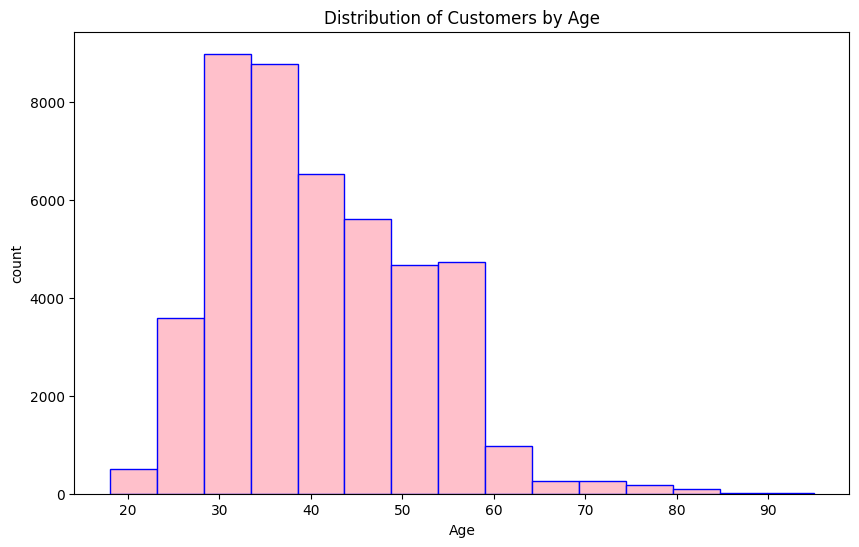

In [90]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=15, color='pink', edgecolor='blue')
plt.xlabel('Age')
plt.ylabel('count')
plt.title('Distribution of Customers by Age')
plt.show()

* what is the distribution of customers by maritial status ? 

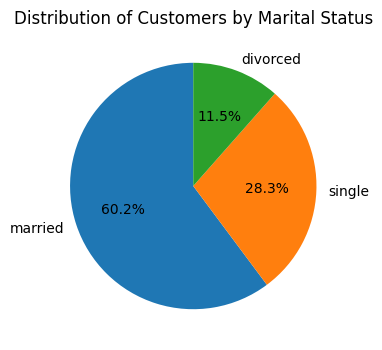

In [91]:
marital_counts = df['marital'].value_counts()
plt.figure(figsize=(8, 4))
plt.pie(marital_counts, labels = marital_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Customers by Marital Status')
plt.show()

what is educational distribution of customer ?

In [92]:
education_counts = df['education'].value_counts()
print(education_counts)

education
secondary    23162
tertiary     13268
primary       6830
unknown       1851
Name: count, dtype: int64


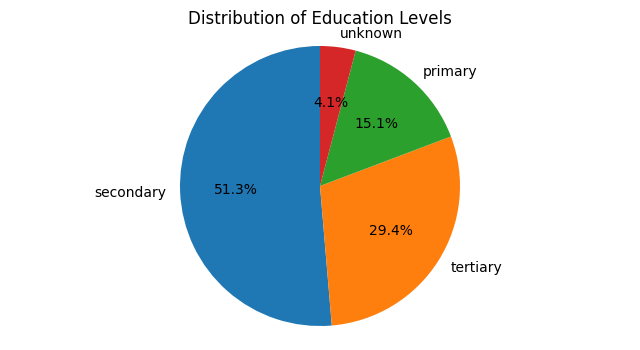

In [93]:
education_counts = df['education'].value_counts()
plt.figure(figsize=(8, 4))
plt.pie(education_counts, labels = education_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Education Levels')
plt.axis('equal')
plt.show()

how many customers have and dont have housing loan? 

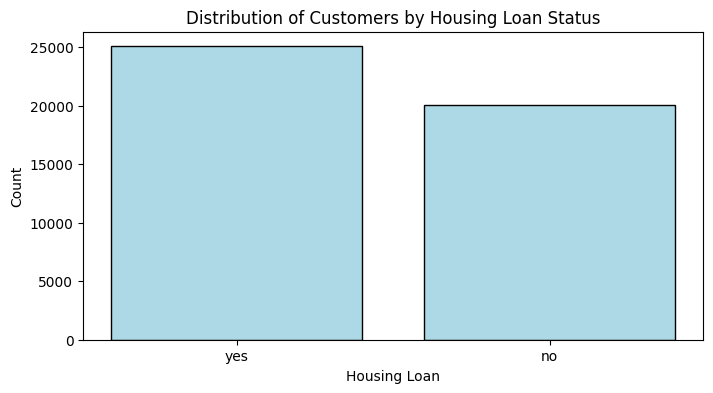

In [94]:
housing_loans_counts = df['housing_loan'].value_counts()

plt.figure(figsize=(8,4))

plt.bar( housing_loans_counts.index, 
        housing_loans_counts.values, 
        color = 'lightblue', edgecolor = 'black') 

plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.title('Distribution of Customers by Housing Loan Status')
plt.show()

how many customers have and dont have personal loan?

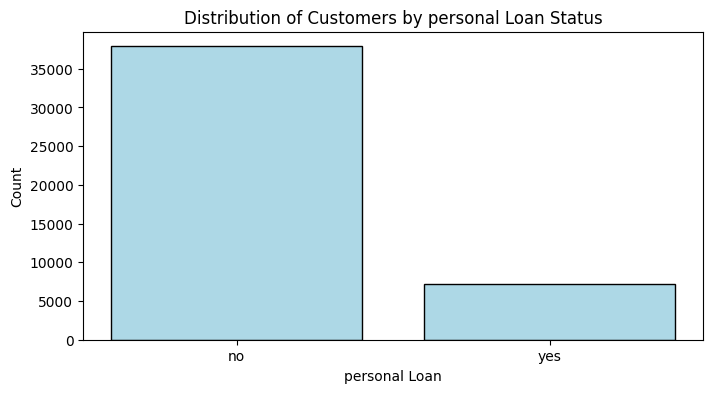

In [95]:
personal_loans_counts = df['personal_loan'].value_counts()

plt.figure(figsize=(8,4))

plt.bar( personal_loans_counts.index, 
        personal_loans_counts.values, 
        color = 'lightblue', edgecolor = 'black') 

plt.xlabel('personal Loan')
plt.ylabel('Count')
plt.title('Distribution of Customers by personal Loan Status')
plt.show()

how are customers distributed accross different job categories?

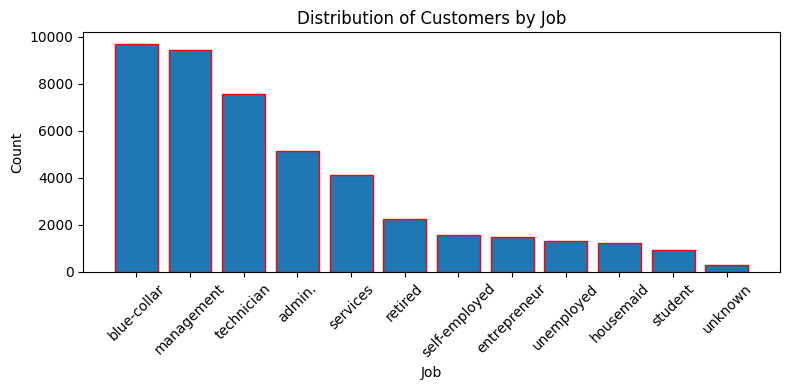

In [96]:
job_counts = df['job'].value_counts()
 
plt.figure(figsize=(8,4))
 
plt.bar(job_counts.index, job_counts.values, edgecolor = 'red')
 
plt.xlabel('Job')
plt.ylabel('Count')
plt.title('Distribution of Customers by Job')
 
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# bi-variate analysis

is  there a realationship between customer age and salary?

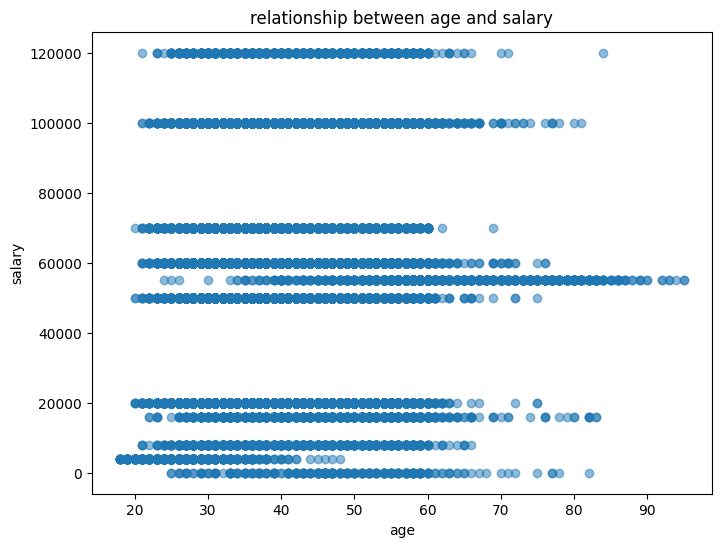

In [97]:
plt.figure(figsize=(8,6))

plt.scatter(df['age'],df ['salary'],alpha =0.5)

plt.xlabel('age')
plt.ylabel('salary')
plt.title('relationship between age and salary')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

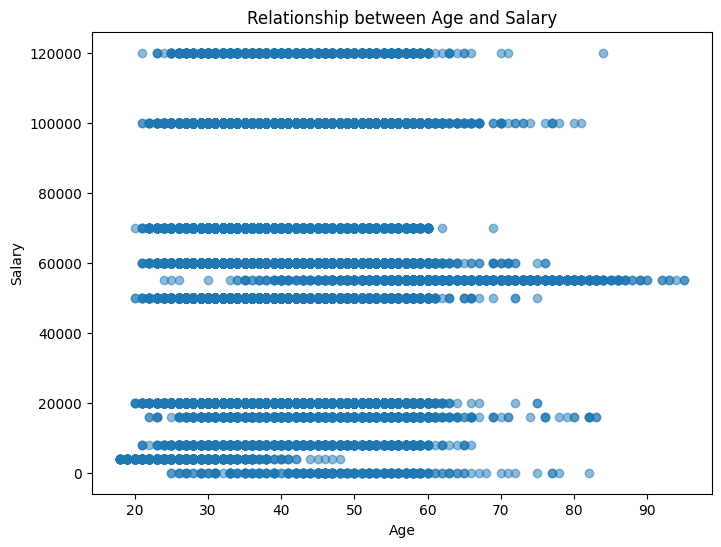

In [98]:
plt.figure(figsize=(8,6))
 
plt.scatter(df['age'],df['salary'], alpha = 0.5)
 
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Relationship between Age and Salary')
plt.show

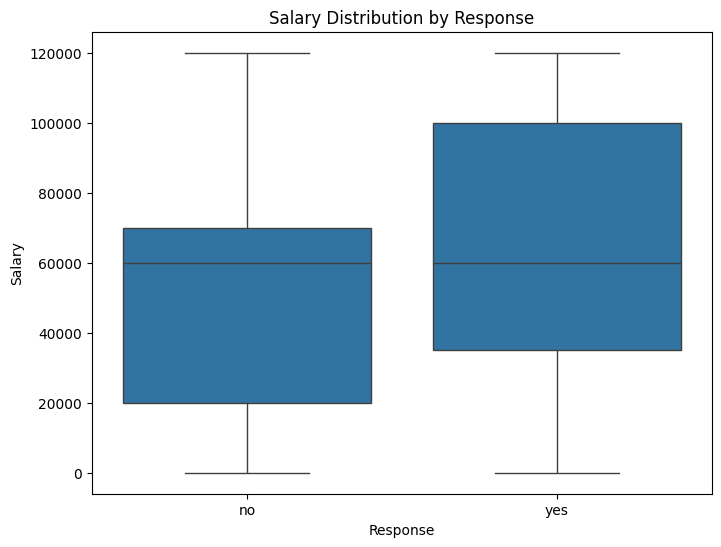

In [99]:
plt.figure(figsize=(8,6))
 
sns.boxplot(x='response', y='salary', data=df)
 
plt.xlabel('Response')
plt.ylabel('Salary')
plt.title('Salary Distribution by Response')
plt.show()
 

9. does the number of customers who respond differ between customer with and without personal loan

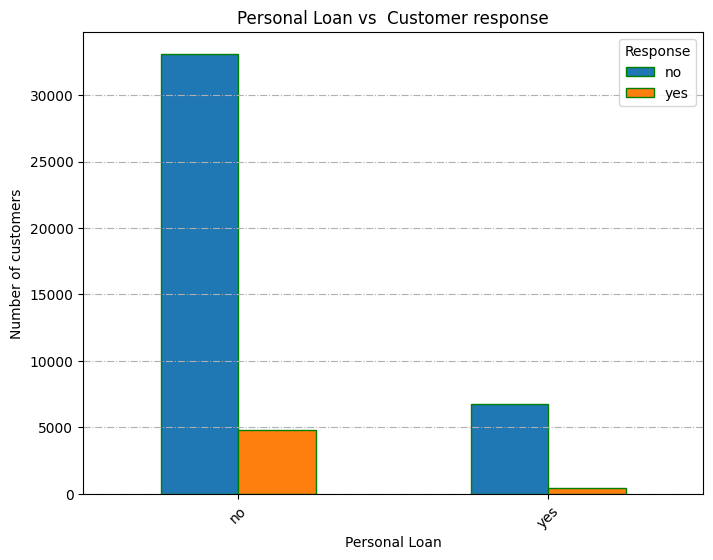

In [103]:
loan_response = pd.crosstab(df['personal_loan'],df['response'])

loan_response.plot(kind = 'bar',figsize=(8,6),edgecolor = 'green')

plt.xlabel('Personal Loan')
plt.ylabel('Number of customers')
plt.title('Personal Loan vs  Customer response')

plt.xticks(rotation = 45)

plt.legend(title="Response")
plt.grid(axis = 'y' ,linestyle = '-.')
plt.show()

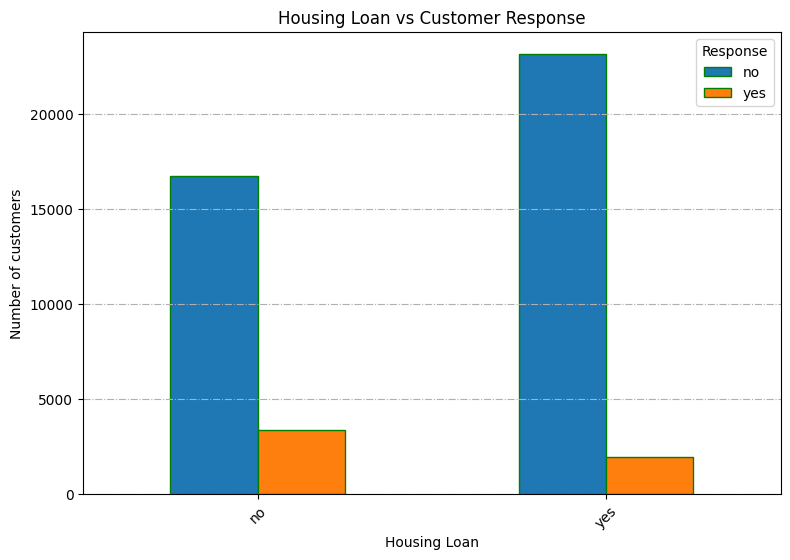

In [110]:
housing_response = pd.crosstab(df['housing_loan'], df['response'])
 
housing_response.plot(kind = 'bar',figsize=(9,6),edgecolor = 'green')
 
plt.xlabel('Housing Loan')
plt.ylabel('Number of customers')
plt.title('Housing Loan vs Customer Response')
 
plt.xticks(rotation = 45)
 
plt.legend(title = "Response")
plt.grid(axis = 'y', linestyle = '-.')
plt.show()

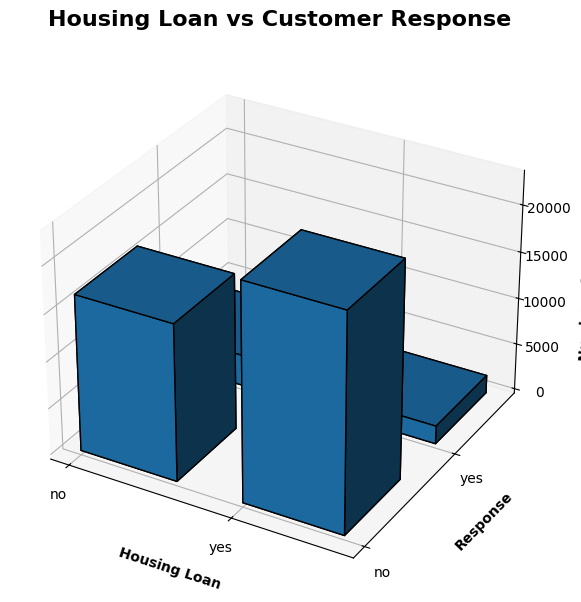

In [113]:
housing_response = pd.crosstab(df['housing_loan'], df['response'])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = range(len(housing_response.index))
y = range(len(housing_response.columns))

xpos, ypos = [], []
zpos = []
dx, dy, dz = [], [], []

for i in range(len(housing_response.index)):
    for j in range(len(housing_response.columns)):
        xpos.append(i)
        ypos.append(j)
        zpos.append(0)
        dx.append(0.6)
        dy.append(0.6)
        dz.append(housing_response.iloc[i, j])

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, edgecolor='black')

ax.set_xlabel('Housing Loan', labelpad=10, fontweight='bold')
ax.set_ylabel('Response', labelpad=10, fontweight='bold')
ax.set_zlabel('Number of Customers', labelpad=10, fontweight='bold')

ax.set_title(
    'Housing Loan vs Customer Response',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xticks(range(len(housing_response.index)))
ax.set_xticklabels(housing_response.index)

ax.set_yticks(range(len(housing_response.columns)))
ax.set_yticklabels(housing_response.columns)

plt.tight_layout()
plt.show()

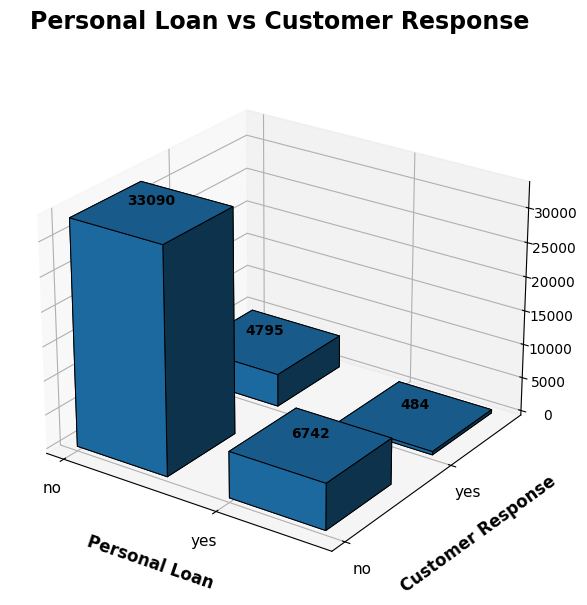

In [114]:
import numpy as np
import matplotlib.pyplot as plt

loan_response = pd.crosstab(
    df['personal_loan'],
    df['response']
)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

# Positions
x = np.arange(len(loan_response.index))
y = np.arange(len(loan_response.columns))

xpos, ypos = np.meshgrid(x, y, indexing='ij')

xpos = xpos.ravel()
ypos = ypos.ravel()

zpos = np.zeros_like(xpos, dtype=float)

dx = np.full_like(xpos, 0.6, dtype=float)
dy = np.full_like(ypos, 0.6, dtype=float)

dz = loan_response.values.ravel()

# 3D bars
ax.bar3d(
    xpos, ypos, zpos,
    dx, dy, dz,
    edgecolor='black',
    linewidth=0.7,
    shade=True
)

# Axis labels
ax.set_xlabel(
    'Personal Loan',
    fontsize=12,
    fontweight='bold',
    labelpad=12
)

ax.set_ylabel(
    'Customer Response',
    fontsize=12,
    fontweight='bold',
    labelpad=12
)

ax.set_zlabel(
    'Number of Customers',
    fontsize=12,
    fontweight='bold',
    labelpad=12
)

# Title
ax.set_title(
    'Personal Loan vs Customer Response',
    fontsize=17,
    fontweight='bold',
    pad=20
)

# Category labels
ax.set_xticks(x)
ax.set_xticklabels(
    loan_response.index,
    fontsize=11
)

ax.set_yticks(y)
ax.set_yticklabels(
    loan_response.columns,
    fontsize=11
)

# Add values on top of bars
for i in range(len(loan_response.index)):
    for j in range(len(loan_response.columns)):
        value = loan_response.iloc[i, j]

        ax.text(
            i + 0.3,
            j + 0.3,
            value + max(dz) * 0.02,
            str(value),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Better 3D viewing angle
ax.view_init(
    elev=25,
    azim=-55
)

plt.tight_layout()
plt.show()